# Active Learning Backtest
**Period:** January 1 – March 25, 2026  
**Starting balance:** $10,000

## Strategy
An adaptive strategy that chooses between **Trust Kalshi** and **Fade Kalshi** based on recent performance:

1. **Exploration phase (trades 1–30):** One strategy is picked at random and used for all 30 trades.
2. **Exploitation phase (every 10 trades after that):** Whichever strategy has higher cumulative P&L is used for the next 10 trades.

Each day, the **10 markets with the largest absolute gap** between model probability and Kalshi mid-price are selected — these are the highest-information trades.

| Parameter | Value |
|-----------|-------|
| Strategy selection | Random for first 30 trades; then re-evaluated every 10 |
| Max trades/day | 10 (highest \|edge\| markets only) |
| Budget/trade | $10 |
| Min edge | None — top-10 selection handles filtering |

**Both strategies are tracked simultaneously** on every trade, so the "which is better" comparison uses full history.

In [1]:
import os, re, json, time, base64, datetime, math, random
from pathlib import Path
from collections import defaultdict

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.backends import default_backend

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

/Users/benjaminthompson/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
KALSHI_KEY_ID   = os.environ.get('KALSHI_KEY_ID', '')
KALSHI_KEY_FILE = os.environ.get('KALSHI_KEY_FILE', '')
KALSHI_BASE     = 'https://api.elections.kalshi.com'

BACKTEST_START      = datetime.date(2026, 1, 1)
BACKTEST_END        = datetime.date(2026, 3, 25)
STARTING_BALANCE    = 10_000.00
MAX_TRADES_PER_DAY  = 10       # top-10 by |edge| each day
BUDGET_USD          = 10.00
INITIAL_RANDOM_TRADES = 30     # random exploration phase length
REEVAL_INTERVAL     = 10       # re-evaluate every N trades after exploration

RANDOM_SEED = 42               # reproducible random initial strategy pick
random.seed(RANDOM_SEED)

ESPN_BASE  = 'http://site.api.espn.com/apis/site/v2/sports'
CACHE_DIR  = Path('backtest_cache')   # reuse cache from backtest.ipynb
CACHE_DIR.mkdir(exist_ok=True)

SPORTS_SERIES = {
    'KXNBAGAME':  ('basketball', 'nba'),
    'KXNHLGAME':  ('hockey',     'nhl'),
    'KXWTAMATCH': ('tennis',     'wta'),
    'KXATPMATCH': ('tennis',     'atp'),
}

# ── Auth ──────────────────────────────────────────────────────────────────────
if not KALSHI_KEY_FILE:
    raise RuntimeError('Set KALSHI_KEY_FILE environment variable')
with open(KALSHI_KEY_FILE, 'rb') as _f:
    _PK = serialization.load_pem_private_key(_f.read(), password=None, backend=default_backend())

def _auth_headers(method, path):
    ts  = str(int(time.time() * 1000))
    msg = ts + method.upper() + path.split('?')[0]
    sig = _PK.sign(msg.encode(),
                   padding.PSS(mgf=padding.MGF1(hashes.SHA256()),
                               salt_length=padding.PSS.DIGEST_LENGTH),
                   hashes.SHA256())
    return {'KALSHI-ACCESS-KEY': KALSHI_KEY_ID,
            'KALSHI-ACCESS-SIGNATURE': base64.b64encode(sig).decode(),
            'KALSHI-ACCESS-TIMESTAMP': ts}

def kalshi_get(path, params=None):
    r = requests.get(KALSHI_BASE + path,
                     headers=_auth_headers('GET', path),
                     params=params, timeout=20)
    r.raise_for_status()
    return r.json()

print('Config ready. Key ID:', KALSHI_KEY_ID[:8], '...')
print(f'Exploration: first {INITIAL_RANDOM_TRADES} trades with a randomly chosen strategy')
print(f'Exploitation: re-evaluate every {REEVAL_INTERVAL} trades thereafter')

Config ready. Key ID: daf6c7c1 ...
Exploration: first 30 trades with a randomly chosen strategy
Exploitation: re-evaluate every 10 trades thereafter


## 1. Load Historical Data (from cache)

In [3]:
MONTH_MAP = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

def parse_ticker_date(series, ticker):
    rest = ticker[len(series)+1:]
    m = re.match(r'^(\d{2})([A-Z]{3})(\d{2})', rest)
    if not m: return None
    try: return datetime.date(2000+int(m.group(1)), MONTH_MAP[m.group(2)], int(m.group(3)))
    except: return None

def load_settled_markets(series):
    cache_file = CACHE_DIR / f'kalshi_{series}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            data = json.load(f)
        print(f'  {series}: {len(data)} markets (cache hit)')
        return data
    markets, cursor, page = [], None, 0
    while page < 35:
        params = {'status': 'settled', 'series_ticker': series, 'limit': 200}
        if cursor: params['cursor'] = cursor
        resp  = kalshi_get('/trade-api/v2/markets', params)
        batch = resp.get('markets', [])
        for m in batch:
            d = parse_ticker_date(series, m.get('ticker', ''))
            if d and BACKTEST_START <= d <= BACKTEST_END:
                m['_series'] = series; m['_game_date'] = d.isoformat()
                markets.append(m)
        cursor = resp.get('cursor'); page += 1
        if not cursor: break
        time.sleep(0.1)
    with open(cache_file, 'w') as f:
        json.dump(markets, f)
    print(f'  {series}: {len(markets)} markets fetched')
    return markets

print('Loading settled markets...')
all_markets = []
for series in SPORTS_SERIES:
    all_markets.extend(load_settled_markets(series))
print(f'\nTotal: {len(all_markets)} settled markets')

Loading settled markets...
  KXNBAGAME: 1196 markets (cache hit)
  KXNHLGAME: 1012 markets (cache hit)
  KXWTAMATCH: 2206 markets (cache hit)
  KXATPMATCH: 2229 markets (cache hit)

Total: 6643 settled markets


In [4]:
# ── ESPN probability model (identical to backtest.ipynb) ──────────────────────
_espn_mem = {}

def _record_win_pct(competitor):
    for rec in competitor.get('records', []):
        if rec.get('type') == 'total':
            m = re.match(r'^(\d+)-(\d+)', rec.get('summary', ''))
            if m:
                w, l = int(m.group(1)), int(m.group(2))
                if w+l > 0: return w/(w+l)
    return None

def _ml_to_implied(ml):
    ml = float(ml)
    return 100.0/(ml+100.0) if ml > 0 else abs(ml)/(abs(ml)+100.0)

def _parse_team_game(event, sport, league):
    comps = event.get('competitions', [])
    if not comps: return None
    comp        = comps[0]
    competitors = comp.get('competitors', [])
    if len(competitors) < 2: return None
    home = next((c for c in competitors if c.get('homeAway')=='home'), competitors[0])
    away = next((c for c in competitors if c.get('homeAway')=='away'), competitors[1])
    hn = home.get('team',{}).get('displayName','')
    an = away.get('team',{}).get('displayName','')
    if not hn or not an: return None
    for odds in comp.get('odds', []):
        hml = odds.get('homeTeamOdds',{}).get('moneyLine')
        aml = odds.get('awayTeamOdds',{}).get('moneyLine')
        if hml and aml:
            hi, ai = _ml_to_implied(hml), _ml_to_implied(aml)
            t = hi+ai
            if t > 0:
                return dict(home=hn, away=an, prob_home=hi/t, prob_away=ai/t,
                            sport=sport, league=league, source='espn_odds')
    hp, ap = _record_win_pct(home), _record_win_pct(away)
    if hp is None and ap is None: return None
    hp = hp or 0.5; ap = ap or 0.5
    t  = hp+ap
    ph = min(0.95, max(0.05, (hp/t)+0.04))
    return dict(home=hn, away=an, prob_home=ph, prob_away=1-ph,
                sport=sport, league=league, source='win_pct')

_tennis_ranks = {}
ranks_cache = CACHE_DIR / 'tennis_rankings.json'
if ranks_cache.exists():
    with open(ranks_cache) as f:
        _tennis_ranks = json.load(f)
    print(f'Tennis rankings loaded ({len(_tennis_ranks)} players)')
else:
    for league in ('atp', 'wta'):
        url = f'{ESPN_BASE}/tennis/{league}/rankings'
        try:
            resp = requests.get(url, timeout=10).json()
            for entry in resp.get('rankings',[{}])[0].get('ranks',[]):
                athlete = entry.get('athlete', {})
                name = athlete.get('displayName', '')
                rank = entry.get('current', 9999)
                if name: _tennis_ranks[name.lower()] = rank
        except: pass
    with open(ranks_cache, 'w') as f:
        json.dump(_tennis_ranks, f)
    print(f'Tennis rankings fetched ({len(_tennis_ranks)} players)')

def _get_rank(name):
    return _tennis_ranks.get(name.lower(), 300)

def _parse_tennis_match(event, sport, league):
    for grouping in event.get('groupings', []):
        for comp_event in grouping.get('competitions', []):
            competitors = comp_event.get('competitors', [])
            if len(competitors) < 2: continue
            p1 = competitors[0].get('athlete',{}).get('displayName','')
            p2 = competitors[1].get('athletes',[{}])[0].get('displayName','') \
                 if competitors[1].get('athletes') else competitors[1].get('athlete',{}).get('displayName','')
            if not p1 or not p2: continue
            r1, r2 = _get_rank(p1), _get_rank(p2)
            l1, l2 = math.log(r1+1), math.log(r2+1)
            p_p1 = min(0.95, max(0.05, l2/(l1+l2)))
            yield dict(home=p1, away=p2, prob_home=p_p1, prob_away=1-p_p1,
                       sport=sport, league=league, source='log_rank')

def get_espn_games(sport, league, date_str):
    key = (sport, league, date_str)
    if key in _espn_mem: return _espn_mem[key]
    cache_path = CACHE_DIR / f'espn_{sport}_{league}_{date_str}.json'
    # Cache stores the already-parsed game list (list of dicts with home/away/prob_home)
    if cache_path.exists():
        with open(cache_path) as f:
            cached = json.load(f)
        if isinstance(cached, list):
            _espn_mem[key] = cached
            return cached
        raw = cached if isinstance(cached, dict) else {}
    else:
        if league in ('atp','wta'):
            url = f'{ESPN_BASE}/tennis/{league}/scoreboard'
        else:
            url = f'{ESPN_BASE}/{sport}/{league}/scoreboard'
        try:
            raw = requests.get(url, params={'dates': date_str}, timeout=10).json()
        except:
            raw = {}
        if not isinstance(raw, dict): raw = {}
    games = []
    if league in ('atp','wta'):
        for event in raw.get('events', []):
            games.extend(_parse_tennis_match(event, sport, league))
    else:
        for event in raw.get('events', []):
            g = _parse_team_game(event, sport, league)
            if g: games.append(g)
    with open(cache_path, 'w') as f:
        json.dump(games, f)
    _espn_mem[key] = games
    return games
def _name_score(name, text):
    text_l = text.lower()
    parts  = [p.strip() for p in name.lower().split() if len(p) > 2]
    return sum(1 for p in parts if p in text_l)

def match_market_to_game(market, games):
    series   = market.get('_series', '')
    title    = market.get('title', '')
    subtitle = market.get('subtitle', '')
    text     = f'{title} {subtitle}'.lower()
    league_filter = SPORTS_SERIES.get(series, ('',''))[1]
    for game in games:
        if game['league'] != league_filter: continue
        h_score = _name_score(game['home'], text)
        a_score = _name_score(game['away'], text)
        if h_score == 0 or a_score == 0: continue
        if h_score + a_score < 2: continue
        is_home_market = _name_score(game['home'], title) >= _name_score(game['away'], title)
        prob = game['prob_home'] if is_home_market else game['prob_away']
        return game, prob
    return None, None

print('Model and matching functions ready.')

Tennis rankings loaded (300 players)
Model and matching functions ready.


## 2. Run the Active Learning Backtest

**Both strategies are computed on every trade.** The active strategy determines which side we actually bet, but the counterfactual P&L for the inactive strategy is also tracked — this is what the re-evaluation uses.

In [5]:
# ── Strategy helper ───────────────────────────────────────────────────────────
def compute_trade_pnl(side, price_yes_ask, price_yes_bid, result):
    """Return (price, contracts, cost, pnl, won) for a given side and result."""
    price    = price_yes_ask if side == 'yes' else (1.0 - price_yes_bid)
    if price < 0.01 or price > 0.99: return None
    contracts = int(BUDGET_USD / price)
    if contracts < 1: return None
    cost = contracts * price
    won  = (side == result)
    pnl  = contracts * (1.0 - price) if won else -cost
    return price, contracts, cost, pnl, won

# ── Active learning state ─────────────────────────────────────────────────────
initial_strategy = random.choice(['trust', 'fade'])
active_strategy  = initial_strategy
print(f'Random seed {RANDOM_SEED}: initial strategy → {active_strategy.upper()} KALSHI')

# Running totals for BOTH strategies on every trade (for re-evaluation)
trust_cumulative = 0.0   # virtual: always trust
fade_cumulative  = 0.0   # virtual: always fade
active_cumulative = 0.0  # actual: using switching strategy

switch_log = []          # record of strategy evaluations / switches

trades   = []
balance  = STARTING_BALANCE
balance_hist = []
trade_count  = 0

# ── Backtest loop ─────────────────────────────────────────────────────────────
markets_by_date = defaultdict(list)
for m in all_markets:
    markets_by_date[m['_game_date']].append(m)

date = BACKTEST_START
while date <= BACKTEST_END:
    date_str    = date.isoformat()
    date_8      = date.strftime('%Y%m%d')
    day_markets = markets_by_date.get(date_str, [])

    all_day_games = []
    for series, (sport, league) in SPORTS_SERIES.items():
        all_day_games.extend(get_espn_games(sport, league, date_8))

    # ── Build candidate list for the day ─────────────────────────────────────
    seen_events  = set()
    candidates   = []

    for market in day_markets:
        event_tk = market.get('event_ticker', market['ticker'])
        if event_tk in seen_events: continue

        try:
            prev_ask = float(market.get('previous_yes_ask_dollars', 0) or 0)
            prev_bid = float(market.get('previous_yes_bid_dollars', 0) or 0)
        except (TypeError, ValueError):
            continue
        if prev_ask < 0.01 or prev_ask > 0.99 or prev_bid < 0.01: continue

        kalshi_mid = (prev_ask + prev_bid) / 2.0
        game, model_prob = match_market_to_game(market, all_day_games)
        if game is None or model_prob is None: continue

        result = market.get('result', '').lower()
        if result not in ('yes', 'no'): continue

        abs_edge = abs(kalshi_mid - model_prob)
        seen_events.add(event_tk)
        candidates.append(dict(
            market=market, kalshi_mid=kalshi_mid, model_prob=model_prob,
            prev_ask=prev_ask, prev_bid=prev_bid, result=result,
            abs_edge=abs_edge, game=game
        ))

    # ── Select top-10 by absolute edge ────────────────────────────────────────
    candidates.sort(key=lambda x: x['abs_edge'], reverse=True)
    day_candidates = candidates[:MAX_TRADES_PER_DAY]

    for cand in day_candidates:
        market     = cand['market']
        kalshi_mid = cand['kalshi_mid']
        model_prob = cand['model_prob']
        prev_ask   = cand['prev_ask']
        prev_bid   = cand['prev_bid']
        result     = cand['result']
        game       = cand['game']

        # Trust side: follow Kalshi direction
        trust_side = 'yes' if kalshi_mid > model_prob else 'no'
        # Fade side:  follow model direction (opposite)
        fade_side  = 'yes' if model_prob > kalshi_mid else 'no'

        trust_result = compute_trade_pnl(trust_side, prev_ask, prev_bid, result)
        fade_result  = compute_trade_pnl(fade_side,  prev_ask, prev_bid, result)
        if trust_result is None or fade_result is None: continue

        t_price, t_contracts, t_cost, t_pnl, t_won = trust_result
        f_price, f_contracts, f_cost, f_pnl, f_won = fade_result

        # Virtual running P&Ls (both strategies, every trade)
        trust_cumulative += t_pnl
        fade_cumulative  += f_pnl

        # Actual trade based on active strategy
        if active_strategy == 'trust':
            a_price, a_contracts, a_cost, a_pnl, a_won, a_side = \
                t_price, t_contracts, t_cost, t_pnl, t_won, trust_side
        else:
            a_price, a_contracts, a_cost, a_pnl, a_won, a_side = \
                f_price, f_contracts, f_cost, f_pnl, f_won, fade_side

        active_cumulative += a_pnl
        balance           += a_pnl
        trade_count       += 1

        trades.append(dict(
            date         = date_str,
            league       = game['league'],
            title        = market.get('title', ''),
            active_strat = active_strategy,
            side         = a_side,
            kalshi_mid   = round(kalshi_mid * 100, 1),
            model_prob   = round(model_prob * 100, 1),
            edge_pp      = round(cand['abs_edge'] * 100, 1),
            contracts    = a_contracts,
            cost         = round(a_cost, 2),
            result       = result,
            won          = a_won,
            pnl          = round(a_pnl, 2),
            trust_pnl    = round(t_pnl, 2),
            fade_pnl     = round(f_pnl, 2),
            trust_cum    = round(trust_cumulative, 2),
            fade_cum     = round(fade_cumulative, 2),
            active_cum   = round(active_cumulative, 2),
            trade_num    = trade_count,
            balance_after= round(balance, 2),
        ))

        # ── Strategy re-evaluation ────────────────────────────────────────────
        is_exploration_boundary = (trade_count == INITIAL_RANDOM_TRADES)
        is_reeval_boundary = (
            trade_count > INITIAL_RANDOM_TRADES and
            (trade_count - INITIAL_RANDOM_TRADES) % REEVAL_INTERVAL == 0
        )

        if is_exploration_boundary or is_reeval_boundary:
            prev_strat = active_strategy
            active_strategy = 'trust' if trust_cumulative >= fade_cumulative else 'fade'
            phase = 'exploration→exploit' if is_exploration_boundary else 'reeval'
            switch_log.append(dict(
                trade_num       = trade_count,
                date            = date_str,
                phase           = phase,
                prev_strat      = prev_strat,
                new_strat       = active_strategy,
                switched        = (prev_strat != active_strategy),
                trust_cum       = round(trust_cumulative, 2),
                fade_cum        = round(fade_cumulative, 2),
            ))

    balance_hist.append({'date': date, 'balance': balance})
    date += datetime.timedelta(days=1)

df     = pd.DataFrame(trades)
bal_df = pd.DataFrame(balance_hist)
bal_df['date'] = pd.to_datetime(bal_df['date'])

print(f'Backtest complete. {trade_count} trades simulated.')
print(f'Initial strategy was: {initial_strategy.upper()} KALSHI')
print(f'Strategy evaluations: {len(switch_log)}')

Random seed 42: initial strategy → TRUST KALSHI
Backtest complete. 58 trades simulated.
Initial strategy was: TRUST KALSHI
Strategy evaluations: 3


## 3. Strategy Switching Log

In [6]:
print('Strategy evaluation log:')
print('─' * 80)
print(f'{"Trade#":<8} {"Date":<12} {"Phase":<22} {"Trust P&L":>10} {"Fade P&L":>10} {"Decision"}')
print('─' * 80)
for ev in switch_log:
    arrow  = '→ SWITCH' if ev['switched'] else '→ KEEP'
    winner = 'TRUST' if ev['trust_cum'] >= ev['fade_cum'] else 'FADE'
    print(f"{ev['trade_num']:<8} {ev['date']:<12} {ev['phase']:<22} "
          f"${ev['trust_cum']:>+9,.2f} ${ev['fade_cum']:>+9,.2f}  "
          f"{arrow} → {ev['new_strat'].upper()}")
print('─' * 80)

Strategy evaluation log:
────────────────────────────────────────────────────────────────────────────────
Trade#   Date         Phase                   Trust P&L   Fade P&L Decision
────────────────────────────────────────────────────────────────────────────────
30       2026-02-25   exploration→exploit    $   +19.93 $   -98.57  → KEEP → TRUST
40       2026-02-26   reeval                 $    -2.87 $   -49.57  → KEEP → TRUST
50       2026-03-25   reeval                 $    -4.28 $   -69.75  → KEEP → TRUST
────────────────────────────────────────────────────────────────────────────────


## 4. Performance Summary

In [7]:
total_pnl     = round(balance - STARTING_BALANCE, 2)
total_return  = round((balance / STARTING_BALANCE - 1) * 100, 2)
n_trades      = len(df)
n_wins        = int(df['won'].sum()) if n_trades else 0
win_rate      = round(n_wins / n_trades * 100, 1) if n_trades else 0
avg_pnl       = round(df['pnl'].mean(), 2) if n_trades else 0
total_wagered = round(df['cost'].sum(), 2) if n_trades else 0

bal_series = bal_df['balance']
peak       = bal_series.cummax()
drawdown   = (bal_series - peak) / peak * 100
max_dd     = round(drawdown.min(), 2)

bal_df['daily_pnl'] = bal_df['balance'].diff().fillna(0)
std_daily = bal_df['daily_pnl'].std()
sharpe    = round((bal_df['daily_pnl'].mean() / std_daily) * (252**0.5), 2) if std_daily > 0 else 0

# Count time spent in each strategy
trust_trades  = int((df['active_strat'] == 'trust').sum()) if n_trades else 0
fade_trades   = int((df['active_strat'] == 'fade').sum())  if n_trades else 0
n_switches    = sum(1 for e in switch_log if e['switched'])

print('═'*58)
print(f'  ACTIVE LEARNING BACKTEST  ({BACKTEST_START} → {BACKTEST_END})')
print('═'*58)
print(f'  Starting balance      :  ${STARTING_BALANCE:>10,.2f}')
print(f'  Ending balance        :  ${balance:>10,.2f}')
print(f'  Total P&L             :  ${total_pnl:>+10,.2f}')
print(f'  Total return          :  {total_return:>+9.2f}%')
print('─'*58)
print(f'  Total trades          :  {n_trades:>10}')
print(f'  Wins / Losses         :  {n_wins} / {n_trades - n_wins}')
print(f'  Win rate              :  {win_rate:>9.1f}%')
print(f'  Avg P&L per trade     :  ${avg_pnl:>+9.2f}')
print(f'  Total wagered         :  ${total_wagered:>10,.2f}')
print('─'*58)
print(f'  Max drawdown          :  {max_dd:>9.2f}%')
print(f'  Sharpe ratio (ann)    :  {sharpe:>9.2f}')
print('─'*58)
print(f'  Initial strategy      :  {initial_strategy.upper()} KALSHI (random)')
print(f'  Trades on Trust       :  {trust_trades}')
print(f'  Trades on Fade        :  {fade_trades}')
print(f'  Strategy switches     :  {n_switches} of {len(switch_log)} evaluations')
print('─'*58)
print(f'  (virtual) Trust P&L   :  ${trust_cumulative:>+9.2f}')
print(f'  (virtual) Fade P&L    :  ${fade_cumulative:>+9.2f}')
print('═'*58)

# Full comparison
ORIGINAL_FADE = dict(
    n_trades=27, wins=5, win_rate=18.5,
    total_pnl=-94.27, total_return=-0.94, total_wagered=267.27,
    avg_pnl=-3.49, max_dd=-1.19, sharpe=-1.57
)
ORIGINAL_TRUST = dict(
    n_trades=71, wins=47, win_rate=66.2,
    total_pnl=-61.44, total_return=-0.61, total_wagered=681.44,
    avg_pnl=-0.87, max_dd=-0.80, sharpe=-1.81
)
THIS = dict(
    n_trades=n_trades, wins=n_wins, win_rate=win_rate,
    total_pnl=total_pnl, total_return=total_return, total_wagered=total_wagered,
    avg_pnl=avg_pnl, max_dd=max_dd, sharpe=sharpe
)
comp = pd.DataFrame({
    'Fade Kalshi\n(10pp, 4/day)':  ORIGINAL_FADE,
    'Trust Kalshi\n(5pp, 20/day)': ORIGINAL_TRUST,
    'Active Learning\n(top-10/day)': THIS
})
comp.index = ['Trades','Wins','Win Rate %','Total P&L $','Return %',
              'Wagered $','Avg P&L/trade $','Max DD %','Sharpe']
print('\nFull strategy comparison:')
display(comp)

══════════════════════════════════════════════════════════
  ACTIVE LEARNING BACKTEST  (2026-01-01 → 2026-03-25)
══════════════════════════════════════════════════════════
  Starting balance      :  $ 10,000.00
  Ending balance        :  $  9,967.19
  Total P&L             :  $    -32.81
  Total return          :      -0.33%
──────────────────────────────────────────────────────────
  Total trades          :          58
  Wins / Losses         :  40 / 18
  Win rate              :       69.0%
  Avg P&L per trade     :  $    -0.57
  Total wagered         :  $    556.81
──────────────────────────────────────────────────────────
  Max drawdown          :      -0.59%
  Sharpe ratio (ann)    :      -1.34
──────────────────────────────────────────────────────────
  Initial strategy      :  TRUST KALSHI (random)
  Trades on Trust       :  58
  Trades on Fade        :  0
  Strategy switches     :  0 of 3 evaluations
──────────────────────────────────────────────────────────
  (virtual) Trust P&

,"Fade Kalshi\n(10pp, 4/day)","Trust Kalshi\n(5pp, 20/day)",Active Learning\n(top-10/day)
Trades,27.00,71.00,58.00
Wins,5.00,47.00,40.00
Win Rate %,18.50,66.20,69.00
Total P&L $,-94.27,-61.44,-32.81
Return %,-0.94,-0.61,-0.33
Wagered $,267.27,681.44,556.81
Avg P&L/trade $,-3.49,-0.87,-0.57
Max DD %,-1.19,-0.80,-0.59
Sharpe,-1.57,-1.81,-1.34


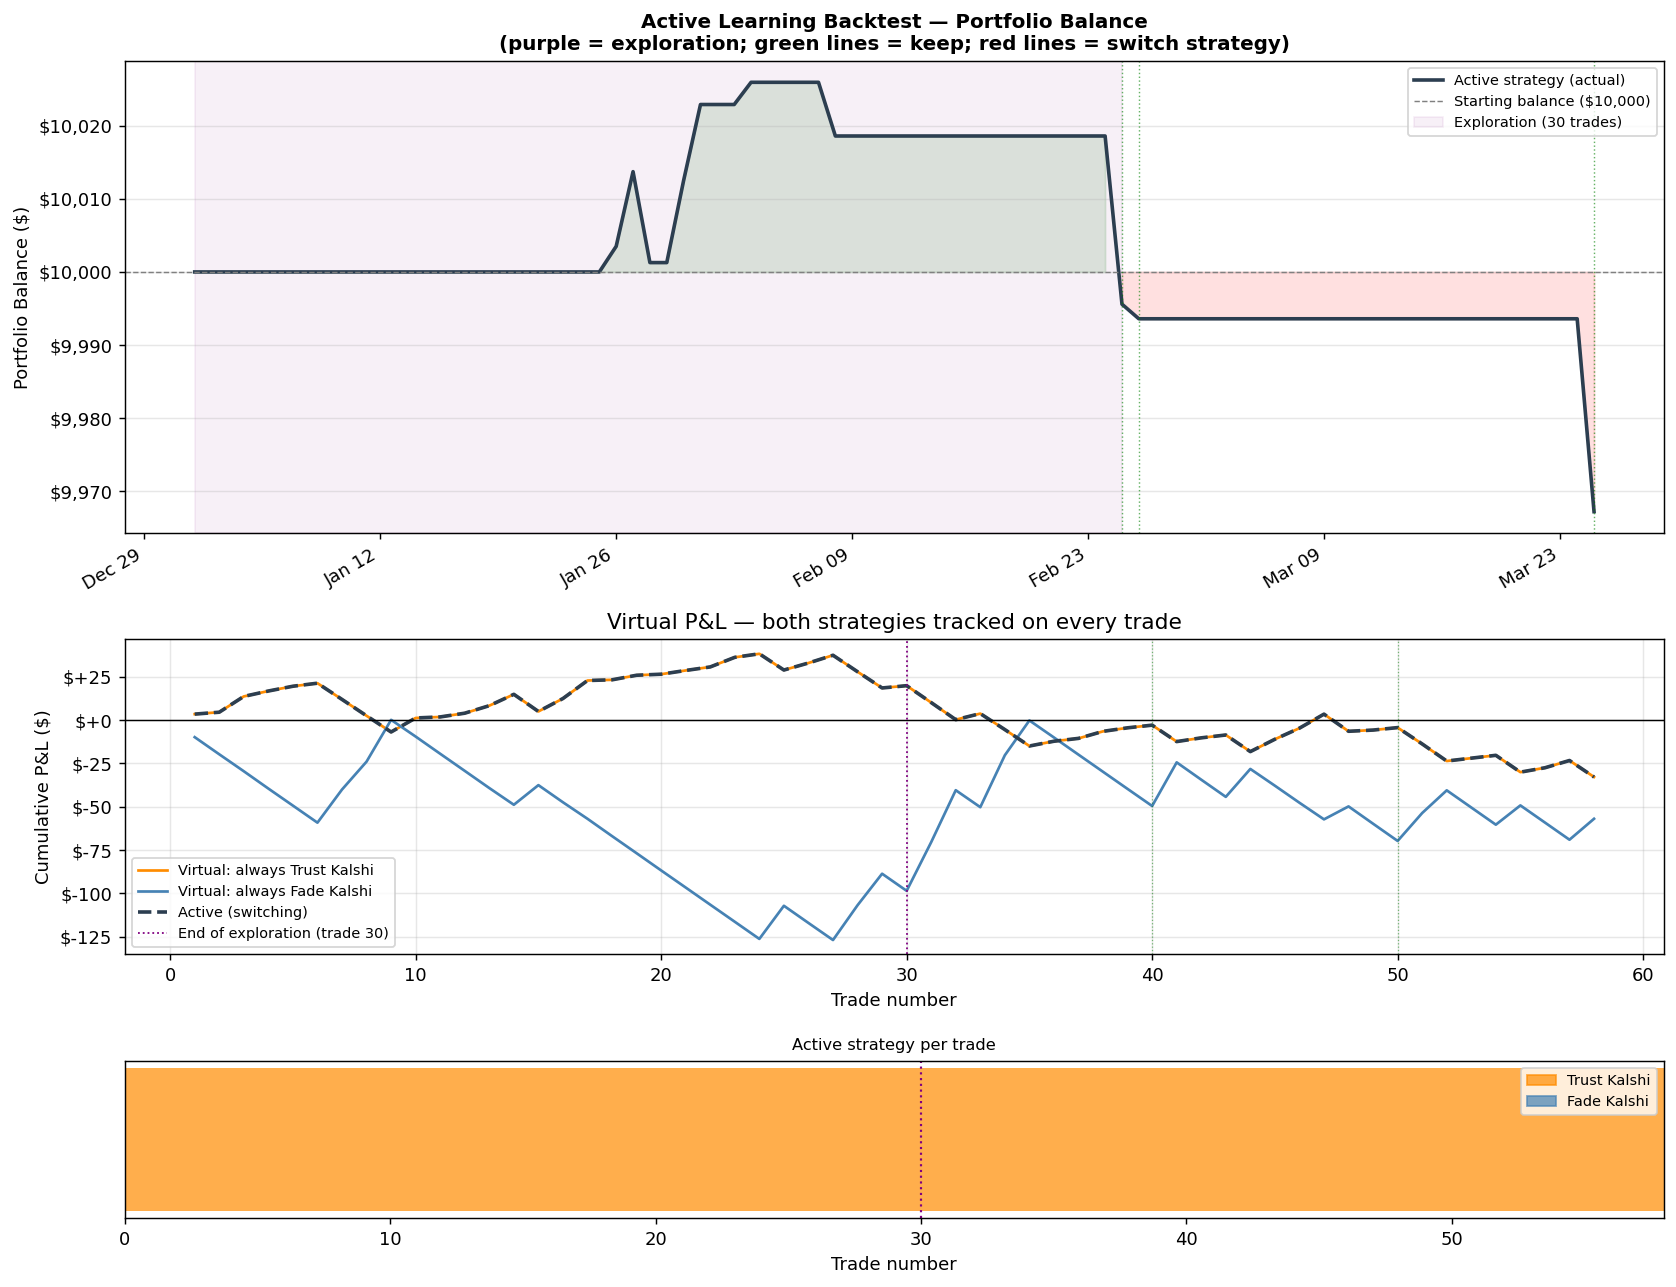

In [8]:
# ── Chart 1: Portfolio value + both virtual P&L lines + strategy bands ─────────
if n_trades == 0:
    print('No trades.')
else:
    df_plot = df.copy()
    df_plot['date_dt'] = pd.to_datetime(df_plot['date'])

    fig, axes = plt.subplots(3, 1, figsize=(13, 10),
                              gridspec_kw={'height_ratios': [3, 2, 1]}, sharex=False)
    ax1, ax2, ax3 = axes

    # ── Panel 1: Portfolio balance ──────────────────────────────────────────
    ax1.plot(bal_df['date'], bal_df['balance'], color='#2c3e50', linewidth=2,
             label='Active strategy (actual)')
    ax1.axhline(STARTING_BALANCE, color='grey', linewidth=0.8, linestyle='--',
                label=f'Starting balance (${STARTING_BALANCE:,.0f})')
    ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                      where=bal_df['balance'] >= STARTING_BALANCE, alpha=0.12, color='green')
    ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                      where=bal_df['balance'] < STARTING_BALANCE, alpha=0.12, color='red')

    # Shade exploration phase
    if switch_log:
        expl_end_date = pd.to_datetime(switch_log[0]['date'])
        ax1.axvspan(bal_df['date'].min(), expl_end_date,
                    alpha=0.06, color='purple', label=f'Exploration ({INITIAL_RANDOM_TRADES} trades)')

    # Mark re-evaluation points
    for ev in switch_log:
        ev_date = pd.to_datetime(ev['date'])
        color   = 'red' if ev['switched'] else 'green'
        ax1.axvline(ev_date, color=color, linewidth=0.8, alpha=0.6, linestyle=':')

    ax1.set_ylabel('Portfolio Balance ($)')
    ax1.set_title('Active Learning Backtest — Portfolio Balance\n'
                  '(purple = exploration; green lines = keep; red lines = switch strategy)',
                  fontsize=11, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    # ── Panel 2: Virtual P&L for both strategies ────────────────────────────
    ax2.plot(df_plot['trade_num'], df_plot['trust_cum'], color='darkorange', linewidth=1.5,
             label='Virtual: always Trust Kalshi')
    ax2.plot(df_plot['trade_num'], df_plot['fade_cum'],  color='steelblue',  linewidth=1.5,
             label='Virtual: always Fade Kalshi')
    ax2.plot(df_plot['trade_num'], df_plot['active_cum'], color='#2c3e50', linewidth=2,
             linestyle='--', label='Active (switching)')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.axvline(INITIAL_RANDOM_TRADES, color='purple', linewidth=1, linestyle=':',
                label=f'End of exploration (trade {INITIAL_RANDOM_TRADES})')
    for ev in switch_log[1:]:   # skip the first one (already marked)
        ax2.axvline(ev['trade_num'], color='red' if ev['switched'] else 'green',
                    linewidth=0.7, alpha=0.5, linestyle=':')
    ax2.set_ylabel('Cumulative P&L ($)')
    ax2.set_xlabel('Trade number')
    ax2.set_title('Virtual P&L — both strategies tracked on every trade')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax2.grid(alpha=0.3)

    # ── Panel 3: Active strategy over time (colour band) ────────────────────
    for i, row in df_plot.iterrows():
        color = 'darkorange' if row['active_strat'] == 'trust' else 'steelblue'
        ax3.barh(0, 1, left=row['trade_num']-1, color=color, height=0.8, alpha=0.7)
    ax3.axvline(INITIAL_RANDOM_TRADES, color='purple', linewidth=1.2, linestyle=':')
    ax3.set_xlim(0, trade_count)
    ax3.set_yticks([])
    ax3.set_xlabel('Trade number')
    ax3.set_title('Active strategy per trade', fontsize=9)
    trust_patch = mpatches.Patch(color='darkorange', alpha=0.7, label='Trust Kalshi')
    fade_patch  = mpatches.Patch(color='steelblue',  alpha=0.7, label='Fade Kalshi')
    ax3.legend(handles=[trust_patch, fade_patch], loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig('active_learning_pnl.png', dpi=130, bbox_inches='tight')
    plt.show()

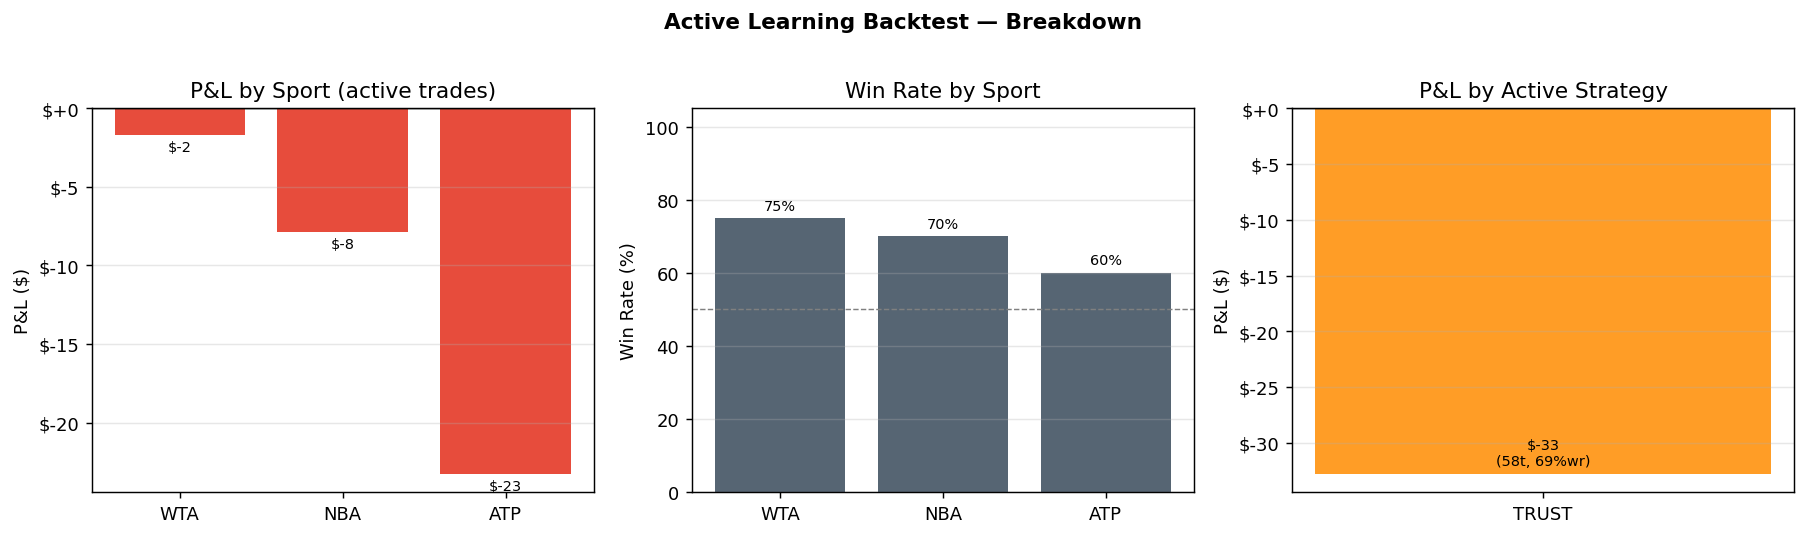

In [9]:
# ── Chart 2: P&L breakdown by sport & edge bin ───────────────────────────────
if n_trades == 0:
    print('No trades.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # P&L by sport
    ax = axes[0]
    sport_grp = df.groupby('league').agg(
        total_pnl=('pnl','sum'), n_trades=('pnl','count'), win_rate=('won','mean')
    ).sort_values('total_pnl', ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sport_grp['total_pnl']]
    bars = ax.bar(sport_grp.index.str.upper(), sport_grp['total_pnl'], color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.bar_label(bars, fmt='${:+.0f}', padding=3, fontsize=8)
    ax.set_title('P&L by Sport (active trades)')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)

    # Win rate by sport
    ax = axes[1]
    wr = sport_grp['win_rate'] * 100
    bars2 = ax.bar(wr.index.str.upper(), wr, color='#2c3e50', alpha=0.8)
    ax.axhline(50, color='grey', linewidth=0.8, linestyle='--')
    ax.bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=8)
    ax.set_title('Win Rate by Sport')
    ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)

    # P&L by strategy that was active
    ax = axes[2]
    strat_grp = df.groupby('active_strat').agg(
        total_pnl=('pnl','sum'), n_trades=('pnl','count'), win_rate=('won','mean')
    )
    strat_colors = {'trust': 'darkorange', 'fade': 'steelblue'}
    bar_colors   = [strat_colors.get(s, 'grey') for s in strat_grp.index]
    bars3 = ax.bar(strat_grp.index.str.upper(), strat_grp['total_pnl'], color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    for bar, (_, row) in zip(bars3, strat_grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'${row["total_pnl"]:+.0f}\n({int(row["n_trades"])}t, {row["win_rate"]*100:.0f}%wr)',
                ha='center', va='bottom', fontsize=8)
    ax.set_title('P&L by Active Strategy')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Active Learning Backtest — Breakdown', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('active_learning_breakdown.png', dpi=130, bbox_inches='tight')
    plt.show()

In [10]:
# ── Trade log ─────────────────────────────────────────────────────────────────
if n_trades:
    disp = df[['date','league','title','active_strat','side',
               'kalshi_mid','model_prob','edge_pp',
               'contracts','cost','result','pnl','balance_after']].copy()
    disp.columns = ['Date','League','Market','Strategy','Side',
                    'Kalshi¢','Model%','Edge pp',
                    'Contracts','Cost $','Result','P&L $','Balance $']
    pd.set_option('display.max_rows', 120)
    display(disp)

,Date,League,Market,Strategy,Side,Kalshi¢,Model%,Edge pp,Contracts,Cost $,Result,P&L $,Balance $
0,2026-01-26,nba,Philadelphia at Charlotte Winner?,trust,no,27.5,47.1,19.6,13,9.49,no,3.51,10003.51
1,2026-01-27,nba,Sacramento at New York Winner?,trust,no,10.5,74.9,64.4,11,9.90,no,1.10,10004.61
2,2026-01-27,nba,Portland at Washington Winner?,trust,yes,51.5,37.8,13.7,19,9.88,yes,9.12,10013.73
3,2026-01-28,nba,Atlanta at Boston Winner?,trust,no,24.5,59.7,35.2,13,9.88,no,3.12,10016.85
4,2026-01-28,nba,Minnesota at Dallas Winner?,trust,yes,76.5,44.1,32.4,12,9.24,yes,2.76,10019.61
5,2026-01-28,nba,Los Angeles L at Cleveland Winner?,trust,no,16.5,46.7,30.2,11,9.24,no,1.76,10021.37
6,2026-01-28,nba,Orlando at Miami Winner?,trust,no,33.5,54.0,20.5,14,9.38,yes,-9.38,10011.99
7,2026-01-28,nba,New York at Toronto Winner?,trust,yes,62.5,47.0,15.5,15,9.45,no,-9.45,10002.54
8,2026-01-28,nba,Chicago at Indiana Winner?,trust,no,28.5,37.8,9.3,13,9.36,yes,-9.36,9993.18
9,2026-01-28,nba,Charlotte at Memphis Winner?,trust,no,45.5,53.0,7.5,18,9.90,no,8.10,10001.28
